<a href="https://colab.research.google.com/github/padman873/sample-sales-analysis/blob/main/sample-sales-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Import necessary libraries
import pandas as pd

print("Pandas library imported successfully!")

Pandas library imported successfully!


In [3]:
# Step 2: Define the file path (it's just the filename since you uploaded it to the session)
file_path = 'sample_sales_data.csv'

# Load the data into a pandas DataFrame
try:
    sales_df = pd.read_csv(file_path)
    print("Sample sales data loaded successfully into a DataFrame!")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Make sure you uploaded it correctly.")
except Exception as e:
    print(f"An error occurred: {e}")

Sample sales data loaded successfully into a DataFrame!


In [4]:
# Step 3: Initial Data Exploration - Display the first few rows and information
print("\nFirst 5 rows of the sales data:")
print(sales_df.head())

print("\nData Info:")
sales_df.info()


First 5 rows of the sales data:
   OrderID CustomerID   OrderDate ProductCategory ProductSubCategory  \
0     1001       C001  2024-01-10     Electronics            Laptops   
1     1002       C002  2024-01-15        Clothing           T-Shirts   
2     1003       C003  2024-01-18     Electronics        Smartphones   
3     1004       C001  2024-01-22        Clothing              Jeans   
4     1005       C004  2024-01-25      Home Goods          Furniture   

   Quantity  UnitPrice  TotalPrice Region CustomerSegment  
0         1     2500.0      2500.0  North      Individual  
1         5       20.0       100.0  South      Individual  
2         2      800.0      1600.0   East  Small Business  
3         1       60.0        60.0  North      Individual  
4         1      400.0       400.0   West      Individual  

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------

In [5]:
# Step 4: Initial Data Exploration - Check shape and missing values
print("\nShape of the DataFrame (rows, columns):")
print(sales_df.shape)

print("\nMissing values per column:")
print(sales_df.isnull().sum())


Shape of the DataFrame (rows, columns):
(10, 10)

Missing values per column:
OrderID               0
CustomerID            0
OrderDate             0
ProductCategory       0
ProductSubCategory    0
Quantity              0
UnitPrice             0
TotalPrice            0
Region                0
CustomerSegment       0
dtype: int64


In [6]:
# Step 5: Initial Data Exploration - Get descriptive statistics and data types
print("\nDescriptive statistics for numerical columns:")
print(sales_df.describe())

print("\nData types:")
print(sales_df.dtypes)


Descriptive statistics for numerical columns:
          OrderID   Quantity    UnitPrice   TotalPrice
count    10.00000  10.000000    10.000000    10.000000
mean   1005.50000   2.700000   737.700000   881.600000
std       3.02765   2.869379   950.175194   953.605462
min    1001.00000   1.000000    15.000000    60.000000
25%    1003.25000   1.000000    31.500000   112.500000
50%    1005.50000   1.500000   390.000000   580.000000
75%    1007.75000   2.750000   795.000000  1395.000000
max    1010.00000  10.000000  2500.000000  2500.000000

Data types:
OrderID                 int64
CustomerID             object
OrderDate              object
ProductCategory        object
ProductSubCategory     object
Quantity                int64
UnitPrice             float64
TotalPrice            float64
Region                 object
CustomerSegment        object
dtype: object


In [7]:
# Step 6: Calculate Total Sales by Product Category
sales_by_category = sales_df.groupby('ProductCategory')['TotalPrice'].sum()

print("\nTotal Sales by Product Category:")
print(sales_by_category)


Total Sales by Product Category:
ProductCategory
Clothing        226.0
Electronics    7280.0
Home Goods     1310.0
Name: TotalPrice, dtype: float64


In [8]:
# Step 7: Calculate Total Sales by Region
sales_by_region = sales_df.groupby('Region')['TotalPrice'].sum()

print("\nTotal Sales by Region:")
print(sales_by_region)


Total Sales by Region:
Region
East     1666.0
North    2710.0
South    3260.0
West     1180.0
Name: TotalPrice, dtype: float64


In [9]:
# Step 8: Calculate Total Sales by Customer Segment
sales_by_segment = sales_df.groupby('CustomerSegment')['TotalPrice'].sum()

print("\nTotal Sales by Customer Segment:")
print(sales_by_segment)


Total Sales by Customer Segment:
CustomerSegment
Individual        4036.0
Small Business    4780.0
Name: TotalPrice, dtype: float64


In [10]:
# Step 9a: Convert 'OrderDate' column to datetime objects
sales_df['OrderDate'] = pd.to_datetime(sales_df['OrderDate'])

print("\n'OrderDate' column converted to datetime.")
print(sales_df.info()) # Check data types again to confirm

# Step 9b: Analyze sales trends by grouping by month
# Extract month and year for grouping
sales_df['OrderMonth'] = sales_df['OrderDate'].dt.to_period('M')

# Calculate total sales per month
monthly_sales = sales_df.groupby('OrderMonth')['TotalPrice'].sum()

print("\nTotal Sales by Month:")
print(monthly_sales)


'OrderDate' column converted to datetime.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   OrderID             10 non-null     int64         
 1   CustomerID          10 non-null     object        
 2   OrderDate           10 non-null     datetime64[ns]
 3   ProductCategory     10 non-null     object        
 4   ProductSubCategory  10 non-null     object        
 5   Quantity            10 non-null     int64         
 6   UnitPrice           10 non-null     float64       
 7   TotalPrice          10 non-null     float64       
 8   Region              10 non-null     object        
 9   CustomerSegment     10 non-null     object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 932.0+ bytes
None

Total Sales by Month:
OrderMonth
2024-01    4660.0
2024-02    4156.0
Freq: M, Name: TotalPr

<ipython-input-11-e942270e4539>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_category.index, y=sales_by_category.values, palette='viridis') # Create the bar plot


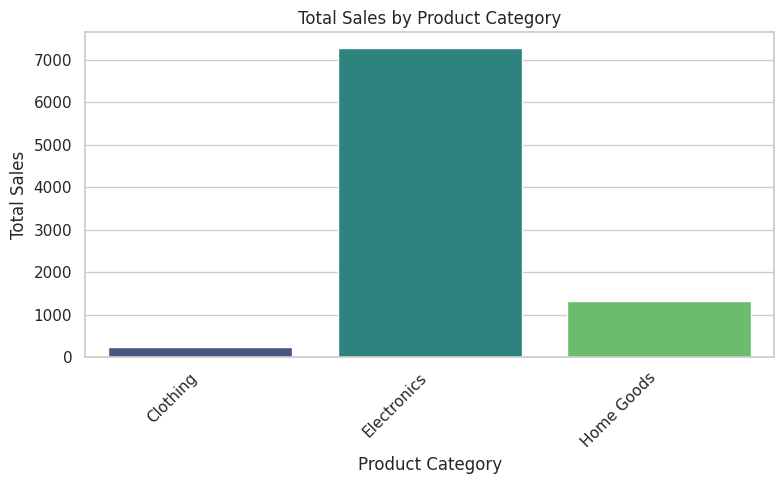


Bar chart showing Total Sales by Product Category displayed.


In [11]:
# Step 10: Visualize Total Sales by Product Category
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style (optional, but makes it look nicer)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5)) # Set the size of the plot
sns.barplot(x=sales_by_category.index, y=sales_by_category.values, palette='viridis') # Create the bar plot

plt.title('Total Sales by Product Category') # Add a title
plt.xlabel('Product Category') # Label the x-axis
plt.ylabel('Total Sales') # Label the y-axis
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels if they are long
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show() # Display the plot

print("\nBar chart showing Total Sales by Product Category displayed.")

**Finding for Chart 1:** The Product Category sales breakdown reveals a significant difference in performance, with Electronics leading, followed by Home Goods, and then Clothing. This highlights where current sales strength lies.

<ipython-input-12-ddc3f60a90ae>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_region.index, y=sales_by_region.values, palette='coolwarm') # Create the bar plot


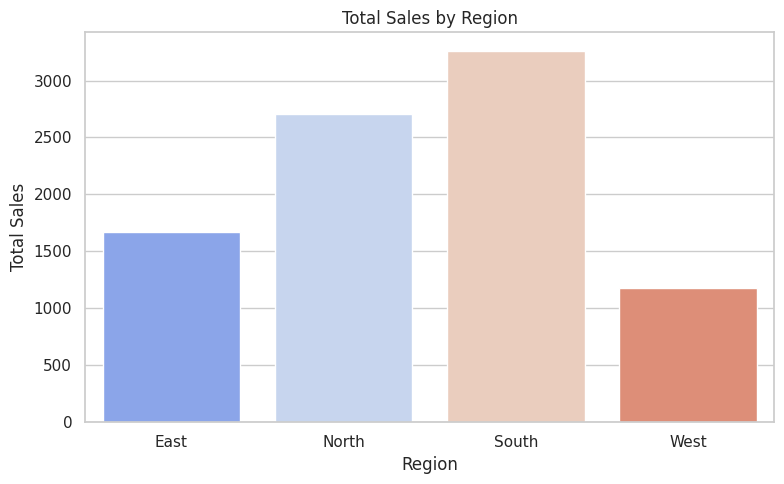


Bar chart showing Total Sales by Region displayed.


In [12]:
# Step 11: Visualize Total Sales by Region
plt.figure(figsize=(8, 5)) # Set the size of the plot
sns.barplot(x=sales_by_region.index, y=sales_by_region.values, palette='coolwarm') # Create the bar plot

plt.title('Total Sales by Region') # Add a title
plt.xlabel('Region') # Label the x-axis
plt.ylabel('Total Sales') # Label the y-axis
plt.tight_layout() # Adjust layout
plt.show() # Display the plot

print("\nBar chart showing Total Sales by Region displayed.")

**Finding for Chart 2:** Sales performance varies by region. The South and North regions are the top two contributors to total sales, while the East and particularly the West regions show lower sales figures.

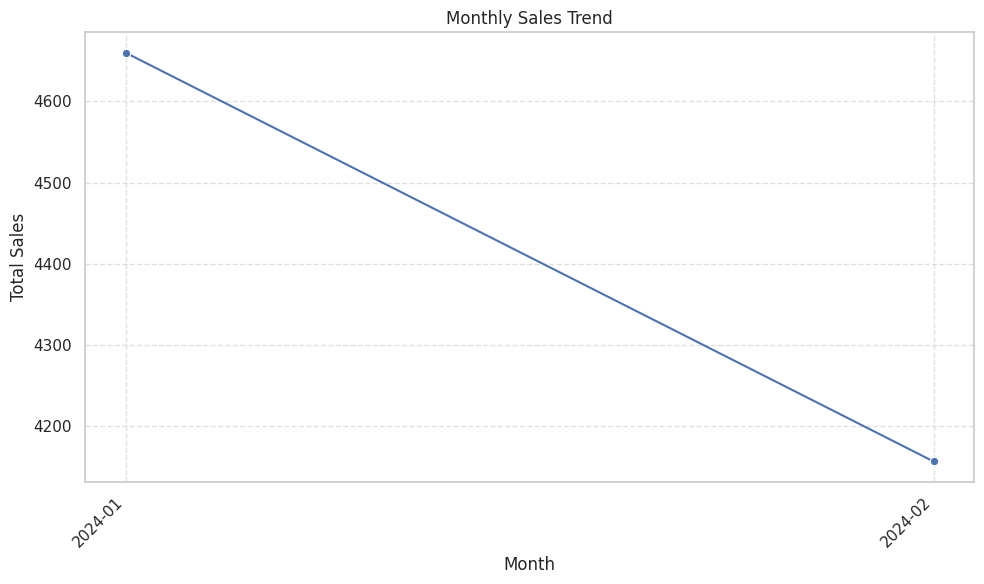


Line chart showing Monthly Sales Trend displayed.


In [13]:
# Step 12: Visualize Total Sales by Month (Sales Trend)
plt.figure(figsize=(10, 6)) # Set a larger size for the time series plot

# Convert the Period objects to strings for plotting on the x-axis if needed,
# or seaborn/matplotlib can often handle Period/datetime indices directly
# Use the index (months) for the x-axis and the values (sales) for the y-axis
sns.lineplot(x=monthly_sales.index.astype(str), y=monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend') # Add a title
plt.xlabel('Month') # Label the x-axis
plt.ylabel('Total Sales') # Label the y-axis
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.grid(True, linestyle='--', alpha=0.6) # Add a grid for better readability
plt.tight_layout() # Adjust layout
plt.show() # Display the plot

print("\nLine chart showing Monthly Sales Trend displayed.")

**Finding for Chart 3:** Monthly sales declined from approximately 4660 in January 2024 to around 4160 in February 2024, indicating a downward trend in this period.

<ipython-input-14-ef30faec647d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_segment.index, y=sales_by_segment.values, palette='pastel') # Create the bar plot


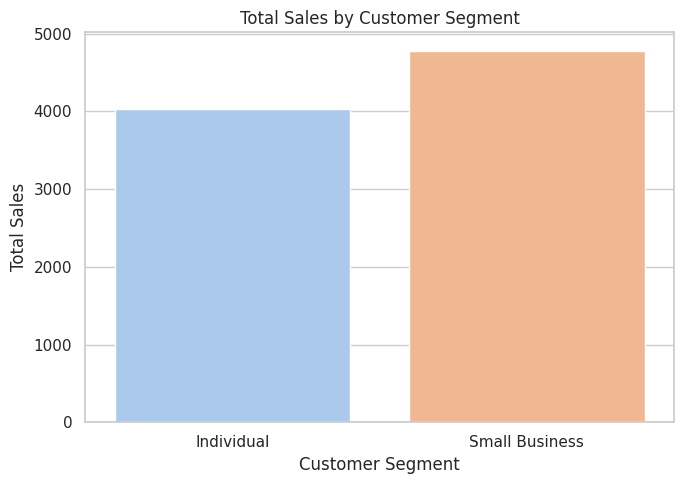


Bar chart showing Total Sales by Customer Segment displayed.


In [14]:
# Step 13: Visualize Total Sales by Customer Segment
plt.figure(figsize=(7, 5)) # Set the size of the plot
sns.barplot(x=sales_by_segment.index, y=sales_by_segment.values, palette='pastel') # Create the bar plot

plt.title('Total Sales by Customer Segment') # Add a title
plt.xlabel('Customer Segment') # Label the x-axis
plt.ylabel('Total Sales') # Label the y-axis
plt.tight_layout() # Adjust layout
plt.show() # Display the plot

print("\nBar chart showing Total Sales by Customer Segment displayed.")

**Finding for Chart 4:** Customer segment analysis shows that the majority of sales revenue came from the Small Business segment rather than individual customers.

## Potential Reasons Behind the Findings

Based on the analysis and general business considerations, here are some potential reasons that **might** explain the observed patterns in the sample sales data. **(Note: These are hypotheses, and confirming them would require looking at more data and business context.)**

### Finding 1: Electronics is the top-selling category, Clothing is the lowest.

* **Why Electronics is high:** This could be driven by high unit prices for electronic products. There might be strong market demand for the specific electronics offered, or recent successful marketing/promotions targeted at this category.
* **Why Clothing is low:** Could be due to lower unit prices compared to other categories, even if many items are sold. Competition in the clothing market might be very high. The current clothing selection might not be popular, or marketing efforts for clothing were limited in this period.

### Finding 2: South and North regions have higher sales than East and West.

* **Potential Reasons:** These regions might have a larger overall population or a higher concentration of the target customer segments. Sales or marketing resources could be more heavily focused on the South and North. Local factors like climate, cultural preferences, or fewer local competitors might favor sales in these regions. Logistical factors like shipping costs or delivery times could potentially hinder sales in the East and West.

### Finding 3: Sales dropped from January to February 2024.

* **Potential Reasons:** This might represent a natural seasonal dip following a potential peak sales period in December/January (e.g., post-holiday slump). It could be influenced by external economic factors or competitor activities in February. An internal factor like inventory shortages, a change in pricing/promotions, or issues with the sales/website could also contribute.

### Finding 4: Small Business segment sales are higher than Individual segment sales.

* **Potential Reasons:** The business model or product offering might be more aligned with business needs, leading to higher demand from this segment. Small businesses often place larger, bulkier orders than individual consumers, even if there are fewer total small business customers. Marketing efforts might be more effectively reaching or targeting the Small Business segment.